Đang phát nhạc Trung Thu...


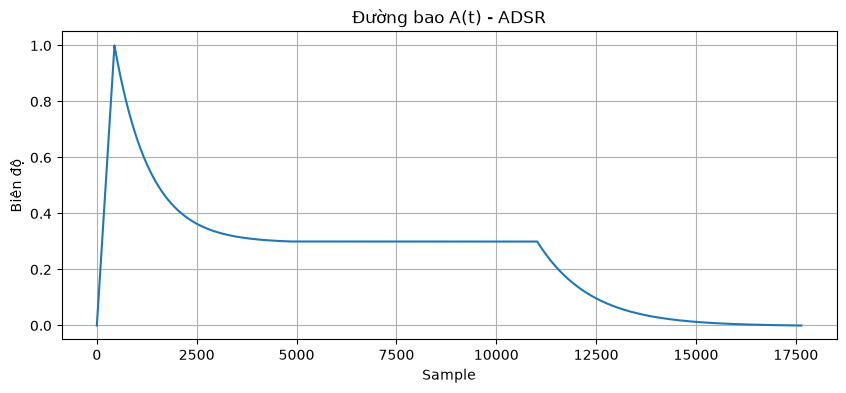

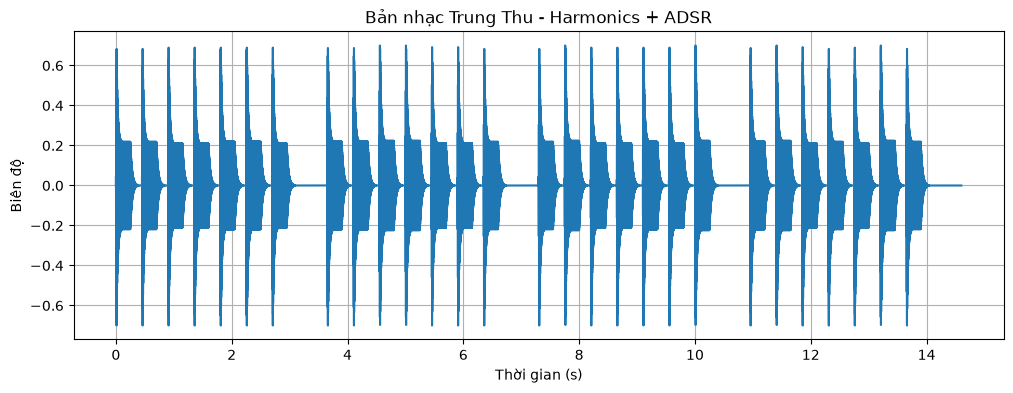

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
import sounddevice as sd


# ============================================================
# 1. THÔNG SỐ
# ============================================================

fs = 44100
A_max = 0.7

note_duration = 0.4
note_pause = 0.05
phrase_pause = 0.5


# ============================================================
# 2. CÁC NỐT NHẠC
# ============================================================

C4 = 40
D4 = 42
E4 = 44
F4 = 45
G4 = 47
A4 = 49


# ============================================================
# 3. GIAI ĐIỆU TRUNG THU
# ============================================================

phrase1 = [C4, C4, G4, G4, A4, A4, G4]

phrase2 = [F4, F4, E4, E4, D4, D4, C4]

phrase3 = [C4, E4, G4, G4, A4, G4, E4]

phrase4 = [F4, E4, D4, C4, G4, E4, C4]

phrases = [
    phrase1,
    phrase2,
    phrase3,
    phrase4
]


# ============================================================
# 4. TẠO BẢN NHẠC
# ============================================================

song = []


for phrase in phrases:

    for n in phrase:

        # ====================================================
        # TÍNH TẦN SỐ NỐT NHẠC
        # ====================================================

        f0 = 440 * 2 ** ((n - 49) / 12)


        # ====================================================
        # TRỤC THỜI GIAN
        # ====================================================

        t = np.arange(
            0,
            note_duration,
            1 / fs
        )

        N = len(t)


        # ====================================================
        # ÂM CHÍNH
        # ====================================================

        x = np.sin(
            2 * np.pi * f0 * t
        )


        # ====================================================
        # CÁC HỌA ÂM
        # ====================================================

        harmonic_amplitudes = [
            0.40,
            0.25,
            0.15,
            0.08,
            0.04
        ]

        for k in range(2, 7):

            Ak = harmonic_amplitudes[k - 2]

            x += Ak * np.sin(
                2 * np.pi * k * f0 * t
            )


        # ====================================================
        # A(t) - ADSR
        # GIỐNG CÁC BÀI TRƯỚC
        # ====================================================

        T_attack = 0.01
        T_decay = 0.10
        T_release = 0.15

        N_attack = int(T_attack * fs)
        N_decay = int(T_decay * fs)
        N_release = int(T_release * fs)

        # Phần còn lại là Sustain
        N_sustain = N - N_attack - N_decay - N_release


        # ----------------------------------------------------
        # ATTACK: 0 -> 1
        # ----------------------------------------------------

        A_attack = np.linspace(
            0,
            1,
            N_attack
        )


        # ----------------------------------------------------
        # DECAY: 1 -> 0.3
        # Hàm mũ
        # ----------------------------------------------------

        u = np.linspace(
            0,
            1,
            N_decay
        )

        k_adsr = 5

        A_decay = 0.3 + 0.7 * (
            (np.exp(-k_adsr * u) - np.exp(-k_adsr))
            / (1 - np.exp(-k_adsr))
        )


        # ----------------------------------------------------
        # SUSTAIN: 0.3
        # ----------------------------------------------------

        A_sustain = np.ones(
            N_sustain
        ) * 0.3


        # ----------------------------------------------------
        # RELEASE: 0.3 -> 0
        # Hàm mũ
        # ----------------------------------------------------

        u = np.linspace(
            0,
            1,
            N_release
        )

        A_release = 0.3 * (
            (np.exp(-k_adsr * u) - np.exp(-k_adsr))
            / (1 - np.exp(-k_adsr))
        )


        # ----------------------------------------------------
        # GHÉP A(t)
        # ----------------------------------------------------

        A_t = np.concatenate([
            A_attack,
            A_decay,
            A_sustain,
            A_release
        ])


        # ====================================================
        # NHÂN TÍN HIỆU VỚI A(t)
        # ====================================================

        x = A_t * x


        # ====================================================
        # CHUẨN HÓA
        # ====================================================

        x = x / np.max(np.abs(x))

        x = A_max * x


        # ====================================================
        # THÊM NỐT VÀO BẢN NHẠC
        # ====================================================

        song.append(x)


        # ====================================================
        # KHOẢNG NGHỈ GIỮA CÁC NỐT
        # ====================================================

        pause = np.zeros(
            int(note_pause * fs)
        )

        song.append(pause)


    # ========================================================
    # KHOẢNG NGHỈ GIỮA CÁC CÂU
    # ========================================================

    pause_phrase = np.zeros(
        int(phrase_pause * fs)
    )

    song.append(pause_phrase)


# ============================================================
# 5. GHÉP TOÀN BỘ BẢN NHẠC
# ============================================================

song = np.concatenate(song)


# ============================================================
# 6. PHÁT ÂM THANH
# ============================================================

print("Đang phát nhạc Trung Thu...")

sd.play(song, fs)
sd.wait()


# ============================================================
# 7. LƯU FILE WAV
# ============================================================

song_int16 = np.int16(
    song * 32767
)

#filename = "nhac_trung_thu_harmonics_adsr.wav"

#write(
#    filename,
#    fs,
#    song_int16
#)

#print("Đã lưu file:", filename)


# ============================================================
# 8. VẼ A(t)
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(A_t)

plt.title("Đường bao A(t) - ADSR")

plt.xlabel("Sample")

plt.ylabel("Biên độ")

plt.grid()

plt.show()


# ============================================================
# 9. VẼ BẢN NHẠC
# ============================================================

t_song = np.arange(
    len(song)
) / fs

plt.figure(figsize=(12, 4))

plt.plot(
    t_song,
    song
)

plt.title(
    "Bản nhạc Trung Thu - Harmonics + ADSR"
)

plt.xlabel("Thời gian (s)")

plt.ylabel("Biên độ")

plt.grid()

plt.show()